In [1]:
!pip install pyspark --quiet
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, window, expr
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
import time
import pandas as pd
import random
from datetime import datetime, timedelta

In [4]:
!pip install pyspark --quiet
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, from_json, window, expr
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
import pandas as pd
import random
from datetime import datetime
import time
spark = SparkSession.builder \
    .appName("Nike_RealTime_Sales_Streaming") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

In [5]:
skus = [f"NKE-{2000+i}" for i in range(10)]
warehouses = ['WH_North','WH_South','WH_East','WH_West']
categories = ['Shoes','Apparel','Accessories']
brands = ['Nike','Jordan','Converse']
def generate_sales_event(n=1):
    events = []
    for _ in range(n):
        events.append({
            "order_id": f"ORD-{random.randint(20000,99999)}",
            "sku": random.choice(skus),
            "brand": random.choice(brands),
            "category": random.choice(categories),
            "warehouse": random.choice(warehouses),
            "units_sold": random.randint(1,20),
            "unit_price": round(random.uniform(50,250),2),
            "order_date": datetime.now()
        })
    return pd.DataFrame(events)
generate_sales_event(5)

,order_id,sku,brand,category,warehouse,units_sold,unit_price,order_date
0,ORD-77651,NKE-2001,Converse,Shoes,WH_South,8,151.34,2025-12-06 13:50:26.960168
1,ORD-62279,NKE-2002,Nike,Apparel,WH_West,16,221.82,2025-12-06 13:50:26.960186
2,ORD-22305,NKE-2002,Jordan,Accessories,WH_South,1,140.07,2025-12-06 13:50:26.960197
3,ORD-82632,NKE-2006,Jordan,Shoes,WH_West,13,122.31,2025-12-06 13:50:26.960205
4,ORD-51917,NKE-2001,Nike,Accessories,WH_North,12,136.13,2025-12-06 13:50:26.960214


In [6]:
schema = StructType([
    StructField("order_id", StringType(), True),
    StructField("sku", StringType(), True),
    StructField("brand", StringType(), True),
    StructField("category", StringType(), True),
    StructField("warehouse", StringType(), True),
    StructField("units_sold", IntegerType(), True),
    StructField("unit_price", DoubleType(), True),
    StructField("order_date", TimestampType(), True)
])

In [7]:
streaming_df = spark.createDataFrame([], schema)
def append_stream(df, n=5):
    new_events = generate_sales_event(n)
    spark_df = spark.createDataFrame(new_events, schema=schema)
    return df.union(spark_df)
streaming_df = append_stream(streaming_df, 5)
streaming_df.show()

+---------+--------+--------+-----------+---------+----------+----------+--------------------+
| order_id|     sku|   brand|   category|warehouse|units_sold|unit_price|          order_date|
+---------+--------+--------+-----------+---------+----------+----------+--------------------+
|ORD-99208|NKE-2008|  Jordan|Accessories|  WH_East|         6|    128.19|2025-12-06 13:51:...|
|ORD-60045|NKE-2001|    Nike|    Apparel|  WH_West|         6|    247.35|2025-12-06 13:51:...|
|ORD-39668|NKE-2002|Converse|Accessories|  WH_West|        15|    100.39|2025-12-06 13:51:...|
|ORD-30095|NKE-2008|  Jordan|Accessories| WH_South|         8|     67.81|2025-12-06 13:51:...|
|ORD-33783|NKE-2000|  Jordan|Accessories| WH_South|        13|    152.78|2025-12-06 13:51:...|
+---------+--------+--------+-----------+---------+----------+----------+--------------------+



In [9]:
kpi_df = streaming_df.groupBy("sku").sum("units_sold") \
    .withColumnRenamed("sum(units_sold)", "total_units_sold")
category_df = streaming_df.groupBy("category").sum("units_sold") \
    .withColumnRenamed("sum(units_sold)", "total_units_sold")
warehouse_df = streaming_df.groupBy("warehouse").sum("units_sold") \
    .withColumnRenamed("sum(units_sold)", "total_units_sold")
print("\n Real-Time KPI: Units Sold per SKU")
kpi_df.show()
print("\n Real-Time KPI: Units Sold per Category")
category_df.show()
print("\n Real-Time KPI: Units Sold per Warehouse")
warehouse_df.show()


 Real-Time KPI: Units Sold per SKU
+--------+----------------+
|     sku|total_units_sold|
+--------+----------------+
|NKE-2008|              14|
|NKE-2001|               6|
|NKE-2002|              15|
|NKE-2000|              13|
+--------+----------------+


 Real-Time KPI: Units Sold per Category
+-----------+----------------+
|   category|total_units_sold|
+-----------+----------------+
|    Apparel|               6|
|Accessories|              42|
+-----------+----------------+


 Real-Time KPI: Units Sold per Warehouse
+---------+----------------+
|warehouse|total_units_sold|
+---------+----------------+
|  WH_East|               6|
|  WH_West|              21|
| WH_South|              21|
+---------+----------------+



In [17]:
for i in range(5):
    streaming_df = append_stream(streaming_df, n=5)
    kpi_df = streaming_df.groupBy("sku").sum("units_sold").withColumnRenamed("sum(units_sold)", "total_units_sold")
    print(f"\n--- Micro-batch {i+1} ---")
    kpi_df.show()
    time.sleep(2)


--- Micro-batch 1 ---
+--------+----------------+
|     sku|total_units_sold|
+--------+----------------+
|NKE-2008|              65|
|NKE-2001|              52|
|NKE-2002|             120|
|NKE-2000|              83|
|NKE-2004|              87|
|NKE-2003|              47|
|NKE-2006|              68|
|NKE-2009|              38|
|NKE-2005|              37|
|NKE-2007|               6|
+--------+----------------+


--- Micro-batch 2 ---
+--------+----------------+
|     sku|total_units_sold|
+--------+----------------+
|NKE-2008|              73|
|NKE-2001|              52|
|NKE-2002|             120|
|NKE-2000|              83|
|NKE-2004|              95|
|NKE-2003|              71|
|NKE-2006|              68|
|NKE-2009|              38|
|NKE-2005|              37|
|NKE-2007|              13|
+--------+----------------+


--- Micro-batch 3 ---
+--------+----------------+
|     sku|total_units_sold|
+--------+----------------+
|NKE-2008|              73|
|NKE-2001|              52|
|NKE-

In [18]:
from pyspark.sql.functions import round
stock_dict = {sku: random.randint(50, 500) for sku in skus}
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType
def get_stock(sku):
    return stock_dict.get(sku, 100)
stock_udf = udf(get_stock, IntegerType())
streaming_df = streaming_df.withColumn("stock_on_hand", stock_udf(col("sku")))
streaming_df = streaming_df.withColumn("revenue", col("units_sold") * col("unit_price"))
kpi_df = streaming_df.groupBy("sku").sum("units_sold", "revenue", "stock_on_hand") \
    .withColumnRenamed("sum(units_sold)", "total_units_sold") \
    .withColumnRenamed("sum(revenue)", "total_revenue") \
    .withColumnRenamed("sum(stock_on_hand)", "total_stock_on_hand")
kpi_df = kpi_df.withColumn("sell_thru_rate", round(col("total_units_sold") / col("total_stock_on_hand"), 2))
print("\n Real-Time KPI: Units Sold, Revenue & Sell-Thru per SKU")
kpi_df.show()


 Real-Time KPI: Units Sold, Revenue & Sell-Thru per SKU
+--------+----------------+-----------------+-------------------+--------------+
|     sku|total_units_sold|    total_revenue|total_stock_on_hand|sell_thru_rate|
+--------+----------------+-----------------+-------------------+--------------+
|NKE-2008|              77|         13467.12|               2240|          0.03|
|NKE-2001|              53|           8586.8|               1776|          0.03|
|NKE-2002|             131|         21255.96|               2180|          0.06|
|NKE-2000|             114|         14750.09|               4530|          0.03|
|NKE-2004|             153|         21109.91|               4631|          0.03|
|NKE-2003|              74|9082.119999999999|               1806|          0.04|
|NKE-2006|              86|         14423.95|               2448|          0.04|
|NKE-2009|              38|          8568.81|                352|          0.11|
|NKE-2005|              88|         11087.64|       

In [19]:
import builtins
import pandas as pd
from datetime import datetime
import random
from pyspark.sql.functions import col, udf, round
from pyspark.sql.types import IntegerType
def generate_sales_event(n=1):
    events = []
    for _ in range(n):
        events.append({
            "order_id": f"ORD-{random.randint(20000,99999)}",
            "sku": random.choice(skus),
            "brand": random.choice(brands),
            "category": random.choice(categories),
            "warehouse": random.choice(warehouses),
            "units_sold": random.randint(1,20),
            "unit_price": builtins.round(random.uniform(50,250),2),
            "order_date": datetime.now()
        })
    return pd.DataFrame(events)
def append_stream(df, n=5):
    new_events = generate_sales_event(n)
    spark_df_new_events = spark.createDataFrame(new_events, schema=schema)
    spark_df_new_events = spark_df_new_events.withColumn("stock_on_hand", stock_udf(col("sku")))
    spark_df_new_events = spark_df_new_events.withColumn("revenue", col("units_sold") * col("unit_price"))
    return df.union(spark_df_new_events)
if "stock_on_hand" not in streaming_df.columns or "revenue" not in streaming_df.columns:
    streaming_df = streaming_df.withColumn("stock_on_hand", stock_udf(col("sku")))
    streaming_df = streaming_df.withColumn("revenue", col("units_sold") * col("unit_price"))
for i in range(5):
    streaming_df = append_stream(streaming_df, n=5)
    kpi_df = streaming_df.groupBy("sku").sum("units_sold", "revenue", "stock_on_hand") \
        .withColumnRenamed("sum(units_sold)", "total_units_sold") \
        .withColumnRenamed("sum(revenue)", "total_revenue") \
        .withColumnRenamed("sum(stock_on_hand)", "total_stock_on_hand") \
        .withColumn("sell_thru_rate", round(col("total_units_sold") / col("total_stock_on_hand"), 2))
    print(f"\n--- Micro-batch {i+1} ---")
    kpi_df.show()
    time.sleep(2)


--- Micro-batch 1 ---
+--------+----------------+------------------+-------------------+--------------+
|     sku|total_units_sold|     total_revenue|total_stock_on_hand|sell_thru_rate|
+--------+----------------+------------------+-------------------+--------------+
|NKE-2008|              77|          13467.12|               2240|          0.03|
|NKE-2001|              53|            8586.8|               1776|          0.03|
|NKE-2002|             148|23708.379999999997|               2398|          0.06|
|NKE-2000|             132|15745.130000000001|               4983|          0.03|
|NKE-2004|             153|          21109.91|               4631|          0.03|
|NKE-2003|              99|          11744.08|               2322|          0.04|
|NKE-2006|              86|          14423.95|               2448|          0.04|
|NKE-2009|              46|           9511.05|                440|           0.1|
|NKE-2005|              88|          11087.64|               2376|         

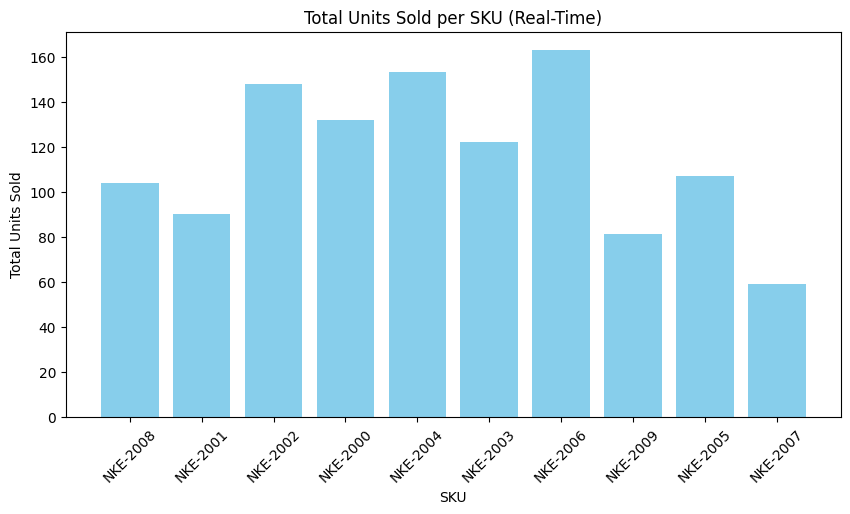

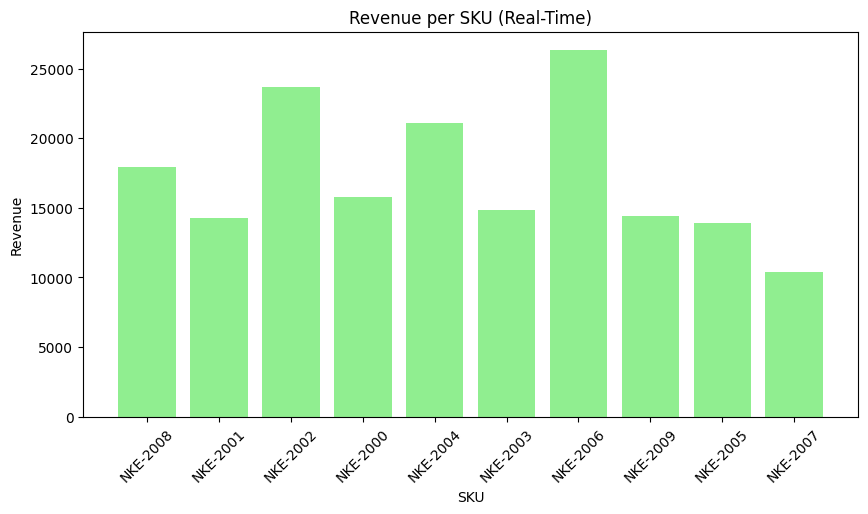

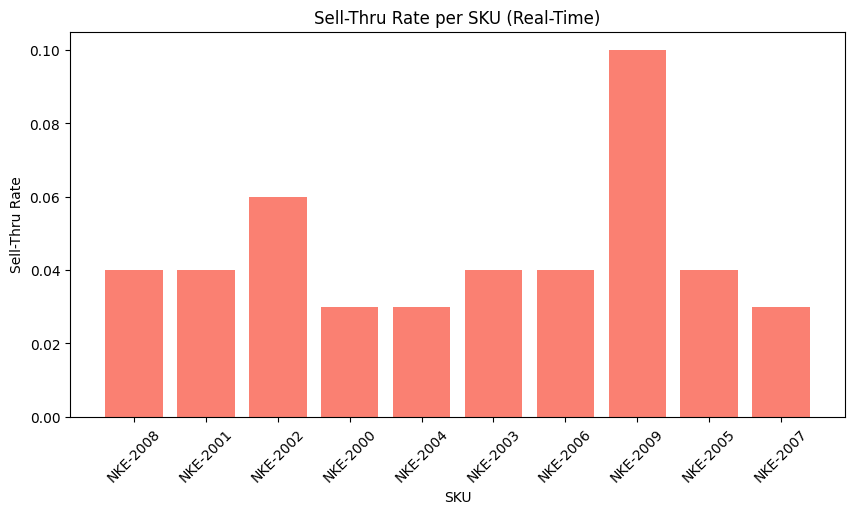

In [22]:
import matplotlib.pyplot as plt
# Convert Spark DataFrame to Pandas for plotting
kpi_pd = kpi_df.toPandas()
# Plot Total Units Sold per SKU
plt.figure(figsize=(10,5))
plt.bar(kpi_pd['sku'], kpi_pd['total_units_sold'], color='skyblue')
plt.title("Total Units Sold per SKU (Real-Time)")
plt.xlabel("SKU")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.show()
# Plot Revenue per SKU
plt.figure(figsize=(10,5))
plt.bar(kpi_pd['sku'], kpi_pd['total_revenue'], color='lightgreen')
plt.title("Revenue per SKU (Real-Time)")
plt.xlabel("SKU")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()
# Plot Sell-Thru Rate per SKU
plt.figure(figsize=(10,5))
plt.bar(kpi_pd['sku'], kpi_pd['sell_thru_rate'], color='salmon')
plt.title("Sell-Thru Rate per SKU (Real-Time)")
plt.xlabel("SKU")
plt.ylabel("Sell-Thru Rate")
plt.xticks(rotation=45)
plt.show()

In [23]:
import plotly.express as px
fig_units = px.bar(kpi_pd, x='sku', y='total_units_sold', title=' Total Units Sold per SKU', text='total_units_sold')
fig_units.show()
fig_revenue = px.bar(kpi_pd, x='sku', y='total_revenue', title=' Revenue per SKU', text='total_revenue')
fig_revenue.show()
fig_sellthru = px.bar(kpi_pd, x='sku', y='sell_thru_rate', title=' Sell-Thru Rate per SKU', text='sell_thru_rate')
fig_sellthru.show()